In [1]:
### First read both revcomp and forward var effects
import pandas as pd

forward = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/2-opentargets_model_variant_effect/agarwal/k562_agarwal_1bp.csv.gz", compression="gzip")
reverse = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/2-opentargets_model_variant_effect/agarwal/k562_agarwal_revcomp_1bp.csv.gz", compression="gzip")

# print(forward.head(1))

### Have to switch the column labels for the forward df
rename_dict = {}
for col in forward.columns:
    if col.startswith("offset_"):
        pos = int(col.split("_")[1])
        flipped_col = f"offset_{-pos}"
        rename_dict[col] = flipped_col

# Apply the renaming
forward = forward.rename(columns=rename_dict)
# print(forward.head(1))

In [2]:
### Now change the values
offset_cols = [col for col in forward.columns if col.startswith("offset_")]
forward[offset_cols] = forward[offset_cols].applymap(lambda x: float(x.strip("[]")) if isinstance(x, str) else x)
forward["seq_id"] = ["seq_" + str(i + 1) for i in range(len(forward))]

reverse[offset_cols] = reverse[offset_cols].applymap(lambda x: float(x.strip("[]")) if isinstance(x, str) else x)
reverse["seq_id"] = ["seq_rev_" + str(i + 1) for i in range(len(reverse))]

/tmp/ipykernel_2227919/2042737668.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  forward[offset_cols] = forward[offset_cols].applymap(lambda x: float(x.strip("[]")) if isinstance(x, str) else x)
/tmp/ipykernel_2227919/2042737668.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  forward["seq_id"] = ["seq_" + str(i + 1) for i in range(len(forward))]
/tmp/ipykernel_2227919/2042737668.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  reverse[offset_cols] = reverse[offset_cols].applymap(lambda x: float(x.strip("[]")) if isinstance(x, str) else x)
/tmp/ipykernel_2227919/2042737668.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fr

In [3]:
### Combine and filter out the rows
forward["strand"] = "forward"
reverse["strand"] = "reverse"
combined = pd.concat([forward, reverse], ignore_index=True)
offset_cols = [col for col in combined.columns if col.startswith("offset_")]
filtered = combined[combined[offset_cols].apply(
    lambda row: (row > 0.5).any() or (row < -0.5).any(), axis=1)]

print(len(filtered))

/tmp/ipykernel_2227919/2790836661.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  forward["strand"] = "forward"
/tmp/ipykernel_2227919/2790836661.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  reverse["strand"] = "reverse"


2418


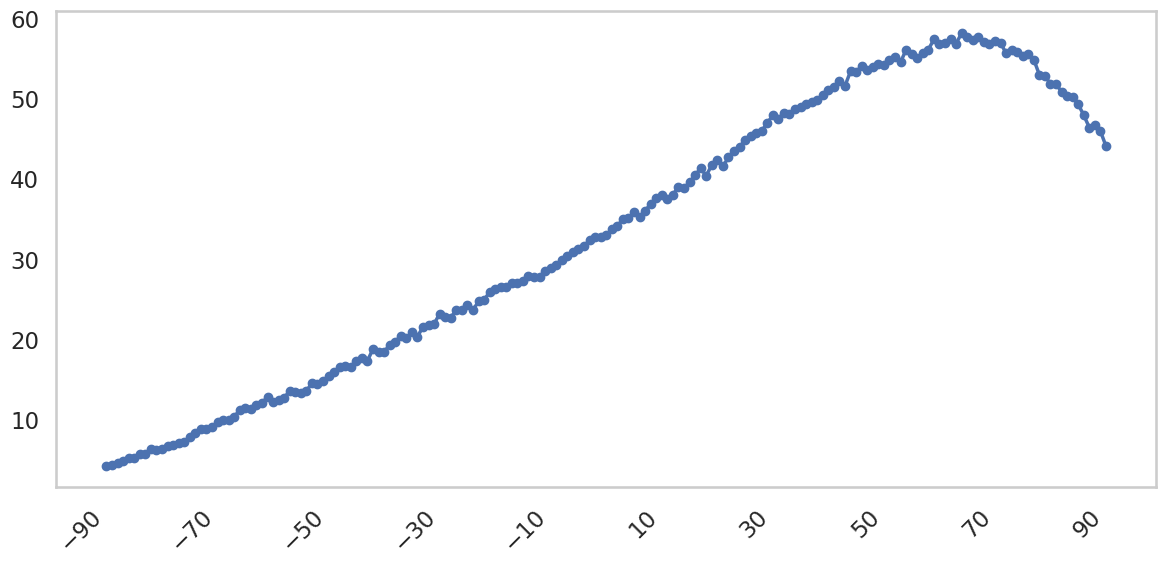

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the offset columns (those like "offset_90", "offset_-90", etc.)
offset_cols = [col for col in filtered.columns if col.startswith("offset_")]
heatmap_data = filtered[offset_cols]

# Extract numeric positions from column names (e.g. "offset_-90" -> -90)
positions = [int(col.split("_")[1]) for col in offset_cols]

# Count rows with value > 0.5 or < -0.5 at each column
counts = ((heatmap_data > 0.5) | (heatmap_data < -0.5)).sum(axis=0).values

# Convert to percentage of total variants
total_variants = heatmap_data.shape[0]
percentages = counts / total_variants * 100

# Build dataframe for plotting
percent_df = pd.DataFrame({
    "position": positions,
    "percent": percentages
}).sort_values("position")

import matplotlib.pyplot as plt
import seaborn as sns

# Use seaborn style for nicer aesthetics
sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(12,6))

# Line with thicker width and larger markers
plt.plot(
    percent_df["position"], 
    percent_df["percent"], 
    marker="o", 
    markersize=6, 
    linewidth=2.5, 
    color="#4C72B0" 
)

# Set ticks every 20 positions
tick_positions = list(range(-90, 91, 20))
plt.xticks(tick_positions, rotation=45, ha='right')

# Light grid
plt.grid(True, linestyle="--", alpha=0)

# Tight layout for publication

plt.tight_layout()

plt.savefig(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/3-cluster/percentage_variants_agarwal.svg",
    format="svg"
)
plt.show()


In [5]:
filtered.head()

,offset_90,offset_89,offset_88,offset_87,offset_86,offset_85,offset_84,offset_83,offset_82,offset_81,...,offset_-83,offset_-84,offset_-85,offset_-86,offset_-87,offset_-88,offset_-89,offset_-90,seq_id,strand
26,-0.210034,-0.204008,-0.241397,-0.170887,-0.196664,-0.227703,-0.241156,-0.243381,-0.229444,-0.241667,...,-0.269777,-0.284773,-0.274853,-0.273174,-0.238442,-0.271740,-0.289046,-0.305404,seq_27,forward
43,0.519007,0.299673,0.104960,0.084042,0.083853,0.052263,0.097757,0.103645,0.097091,0.115216,...,0.025072,0.031264,0.064569,0.008355,0.001208,0.010883,-0.007987,0.008948,seq_44,forward
124,-0.450968,-0.511077,-0.507582,-0.432271,-0.426929,-0.483766,-0.605714,-0.436920,-0.488547,-0.536223,...,-0.108318,-0.045795,-0.076333,-0.091679,-0.057900,-0.054296,-0.044970,-0.064279,seq_125,forward
144,-0.081436,-0.131727,-0.044011,-0.202679,-0.020560,-0.110933,-0.107259,-0.081749,-0.088245,-0.097632,...,-0.464953,-0.476953,-0.417352,-0.559823,-0.504925,-0.513847,-0.694984,-0.585328,seq_145,forward
195,0.194532,0.270793,0.306240,0.232797,0.213283,0.341493,0.300865,0.361905,0.312764,0.091141,...,0.117144,0.116246,0.120795,0.108825,0.110839,0.094037,0.108568,0.105992,seq_196,forward


In [6]:
filtered[offset_cols] = filtered[offset_cols].apply(lambda row: row / row.loc[row.abs().idxmax()], axis=1)
filtered.head(2)

/tmp/ipykernel_2227919/18384593.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered[offset_cols] = filtered[offset_cols].apply(lambda row: row / row.loc[row.abs().idxmax()], axis=1)


,offset_90,offset_89,offset_88,offset_87,offset_86,offset_85,offset_84,offset_83,offset_82,offset_81,...,offset_-83,offset_-84,offset_-85,offset_-86,offset_-87,offset_-88,offset_-89,offset_-90,seq_id,strand
26,0.33562,0.325991,0.385736,0.273066,0.314255,0.363853,0.385351,0.388907,0.366636,0.386167,...,0.431085,0.455047,0.439196,0.436513,0.381014,0.434222,0.461875,0.488015,seq_27,forward
43,1.00000,0.577398,0.202232,0.161929,0.161564,0.100697,0.188354,0.199699,0.187072,0.221993,...,0.048307,0.060238,0.124408,0.016098,0.002328,0.020970,-0.015389,0.017240,seq_44,forward


/arc/project/st-cdeboer-1/sambina/miniconda3/envs/dream_rocky/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


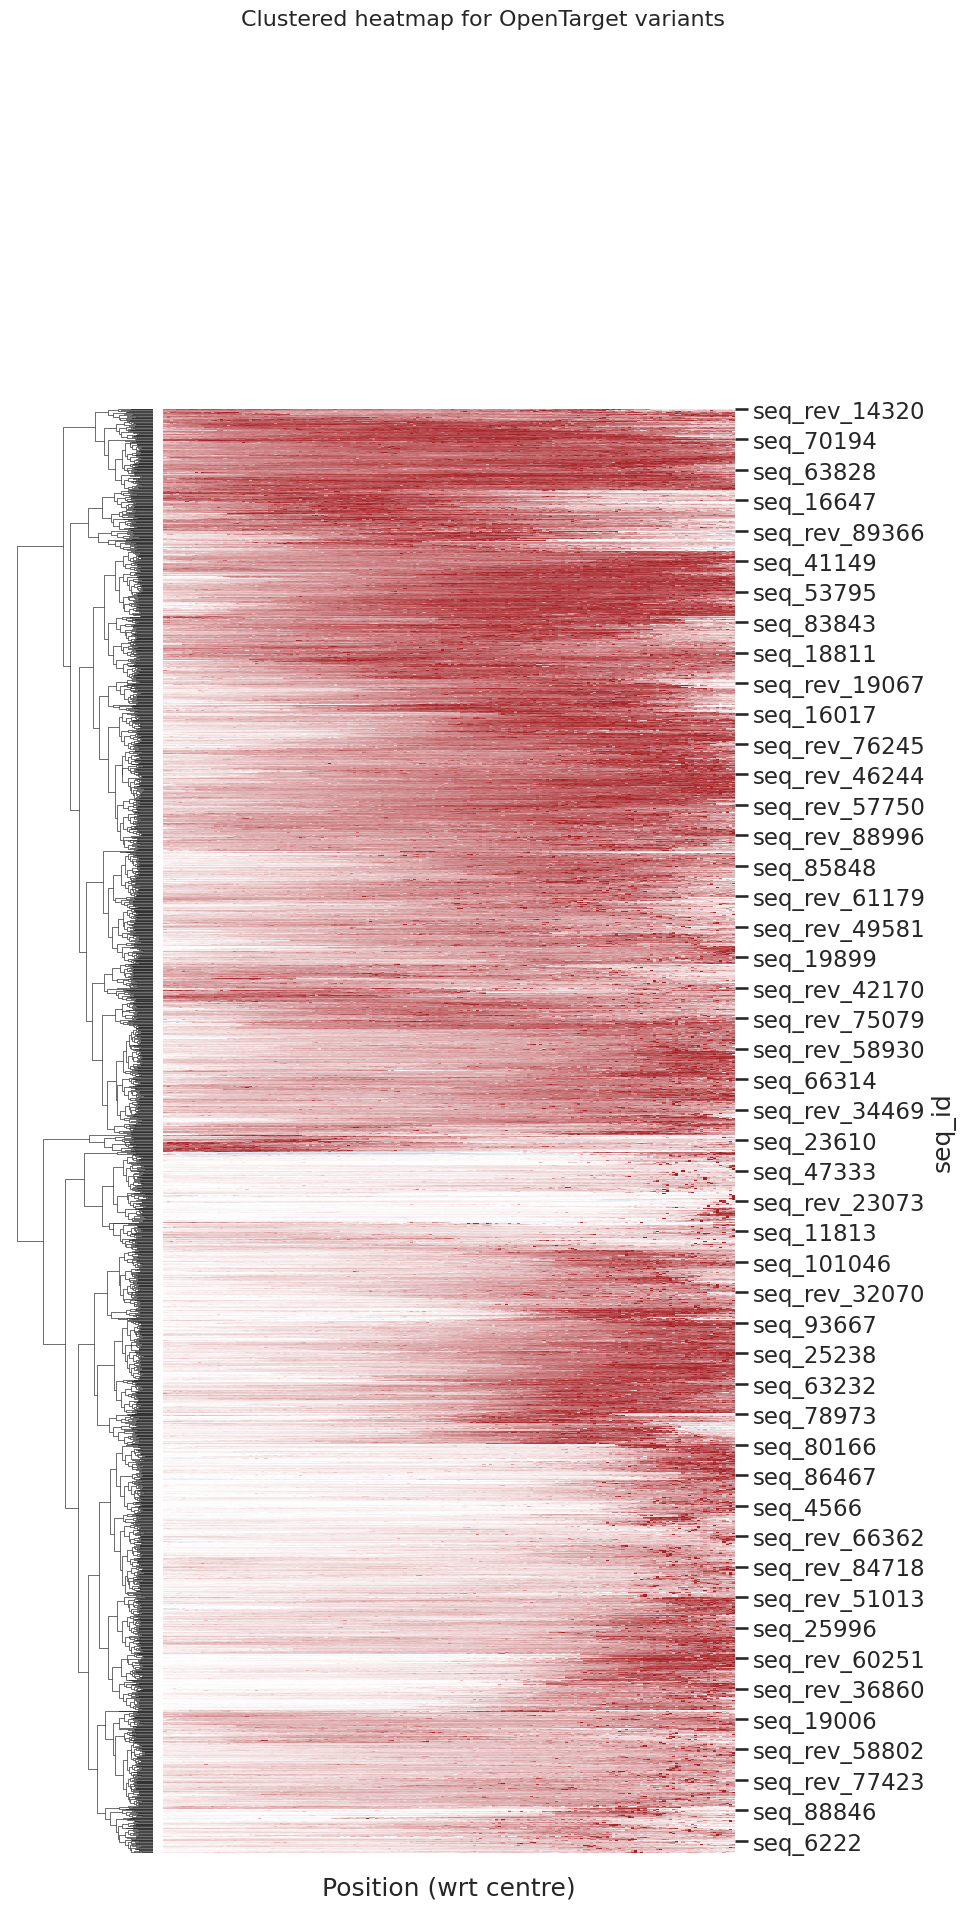

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


# new_offset_cols = sorted(renamed_cols.values(), key=lambda x: int(x.split('_')[1]))
new_offset_cols = sorted(offset_cols, key=lambda x: int(x.split('_')[1]))

heatmap_data = filtered[new_offset_cols]
heatmap_data.index = filtered['seq_id']  

colors = ['#3361A5', '#ffffff', '#A52126']

cmap = LinearSegmentedColormap.from_list('custom_red_black_blue', colors, N=256)

g = sns.clustermap(
    heatmap_data,    
    cmap=cmap,
    metric='euclidean', 
    method='complete',
    figsize=(10,20),
    annot=False,           
    col_cluster=False,    
    z_score=None,
    standard_scale=None,
    vmin=-1,
    vmax=1
)

g.cax.set_position([0, .3, .02, .4])
g.cax.set_ylabel("scaled predicted variant effect", rotation=90, labelpad=12)
g.cax.set_visible(False)

positions = list(range(-90, 91, 20))  # -90, -80, ..., 80, 90
tick_positions = [pos + 90 for pos in positions]  # shift positions to 0-based indices

g.ax_heatmap.set_xticks(tick_positions)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=18)
g.ax_heatmap.set_xlabel("Position (wrt centre)")
g.ax_heatmap.set_ylabel("seq_id")
g.fig.suptitle("Clustered heatmap for OpenTarget variants", y=1.001, fontsize=16, ha='center')
plt.savefig(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/cluster/heatmap_OT_agarwal.png",
    dpi=600,               
    bbox_inches="tight"
)
plt.show()


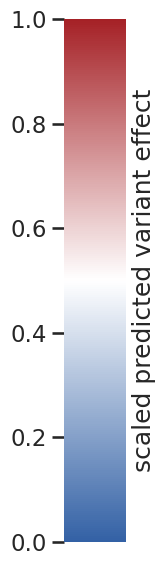

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colorbar import ColorbarBase

colors = ['#3361A5', '#ffffff', '#A52126']
cmap = LinearSegmentedColormap.from_list('custom_red_black_blue', colors, N=256)

fig, ax = plt.subplots(figsize=(2, 6))  # Tall, narrow for colorbar
norm = Normalize(vmin=0, vmax=1)         # Match heatmap scale

cb = ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label("scaled predicted variant effect")

# Remove border and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(left=False, right=False, labelleft=True)  # Keep labels, remove ticks
ax.yaxis.set_ticks_position('left')                      # Keep ticks on left side only if you want labels

plt.tight_layout()

# Save the colorbar as SVG and PNG
cb_path_svg = "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/cluster/colorbar.svg"
cb_path_png = "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/cluster/colorbar.png"

fig.savefig(cb_path_svg, dpi=300, bbox_inches='tight', transparent=True)
fig.savefig(cb_path_png, dpi=300, bbox_inches='tight', transparent=True)

plt.show()

